In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.nonparametric import kaplan_meier_estimator
import warnings
warnings.filterwarnings("ignore")


In [2]:
## WAC Price Increase Survival Analysis
# **Question:** Given a drug's current state, how long until its next WAC price increase?
# **Framing:** Each "spell" = time between consecutive price changes per material.
#   - event=True  → next price increase was observed within the window
#   - event=False → still waiting (censored at last observed date)

# ── Load COPA ──
copa = pd.read_csv("/Users/vishnu.gorur/PycharmProjects/JupyterProject/data/real_data/No_leakage_Active_COPA_data.csv")
copa["WAC_PRICE_COPA_DATE"] = pd.to_datetime(copa["WAC_PRICE_COPA_DATE"])
copa = (copa.sort_values(["COPA_MTRL_NUM","WAC_PRICE_COPA_DATE"])
            .drop_duplicates(["COPA_MTRL_NUM","WAC_PRICE_COPA_DATE"]))

# Flag price changes
copa["_price_changed"] = (copa.groupby("COPA_MTRL_NUM")["BASELINE_WAC_PRICE"]
                              .transform(lambda x: x.ne(x.shift()).astype(int)))
copa.loc[copa.groupby("COPA_MTRL_NUM").head(1).index, "_price_changed"] = 0

# ── Helper: compute historical price-change features for each spell ──
# All features use ONLY data before spell start_date — no future leakage.
def compute_spell_features(grp, s_idx, start_date):
    hist_grp    = grp[grp["WAC_PRICE_COPA_DATE"] < start_date]
    change_rows = hist_grp[hist_grp["_price_changed"] == 1]

    def pct_change(i):
        prev = grp.iloc[i - 1]["BASELINE_WAC_PRICE"]
        curr = grp.iloc[i]["BASELINE_WAC_PRICE"]
        return (curr - prev) / prev * 100 if prev > 0 else 0.0

    change_events = [(grp.iloc[i]["WAC_PRICE_COPA_DATE"], pct_change(i))
                     for i in change_rows.index]

    cutoff_24m = start_date - pd.DateOffset(months=24)
    cutoff_36m = start_date - pd.DateOffset(months=36)

    # time since last increase (months)
    if change_events:
        time_since_last = round((start_date - change_events[-1][0]).days / 30.44, 1)
    else:
        time_since_last = 0.0

    pcts_36m = [p for d, p in change_events if d >= cutoff_36m]

    # compound annualised rate over last 3 years
    price_now = grp.iloc[s_idx]["BASELINE_WAC_PRICE"]
    old_rows  = hist_grp[hist_grp["WAC_PRICE_COPA_DATE"] <= cutoff_36m]
    if len(old_rows) > 0 and old_rows.iloc[-1]["BASELINE_WAC_PRICE"] > 0:
        compound = (price_now / old_rows.iloc[-1]["BASELINE_WAC_PRICE"]) ** (1 / 3) - 1
    else:
        compound = 0.0

    # has increased in each of last 3 calendar years
    years_changed = {d.year for d, _ in change_events if d >= cutoff_36m}
    needed_years  = [y for y in [start_date.year - 1, start_date.year - 2, start_date.year - 3]
                     if y >= grp["WAC_PRICE_COPA_DATE"].min().year]
    every_year = int(all(y in years_changed for y in needed_years)) if needed_years else 0

    return {
        "time_since_last_increase":          time_since_last,
        "num_increases_last_24m":            sum(1 for d, _ in change_events if d >= cutoff_24m),
        "increase_spell_length":             time_since_last,          # prev stable period length
        "month":                             start_date.month,
        "jan_jul_indicator":                 int(start_date.month in [1, 7]),
        "prior_pct_increase":                change_events[-1][1] if change_events else 0.0,
        "rolling_avg_increase_36m":          float(np.mean(pcts_36m)) if pcts_36m else 0.0,
        "max_increase_last_3yrs":            float(np.max(pcts_36m))  if pcts_36m else 0.0,
        "compound_increase_rate":            compound,
        "has_increased_every_year_last_3yrs": every_year,
        "increase_volatility_low_flag":      int(np.std(pcts_36m) < 2.0) if len(pcts_36m) >= 2 else 0,
    }

# ── Build one spell per price-stable interval ──
obs_end = copa["WAC_PRICE_COPA_DATE"].max()
records = []

for mtrl, grp in copa.groupby("COPA_MTRL_NUM"):
    grp = grp.sort_values("WAC_PRICE_COPA_DATE").reset_index(drop=True)
    change_idx = grp.index[grp["_price_changed"] == 1].tolist()
    spell_starts = [0] + change_idx
    spell_ends   = change_idx + [None]

    for spell_num, (s_idx, e_idx) in enumerate(zip(spell_starts, spell_ends)):
        start_row  = grp.iloc[s_idx]
        start_date = start_row["WAC_PRICE_COPA_DATE"]

        if e_idx is not None:
            end_date = grp.iloc[e_idx]["WAC_PRICE_COPA_DATE"]
            duration = max(round((end_date - start_date).days / 30.44), 1)
            event    = True
        else:
            duration = max(round((obs_end - start_date).days / 30.44), 1)
            event    = False

        spell_feats = compute_spell_features(grp, s_idx, start_date)
        rec = {
            "COPA_MTRL_NUM":   mtrl,
            "SPELL_START_DATE": start_date,
            "SELL_DSCR":       start_row["SELL_DSCR"],
            "CUST_PROD_CATEGORY": start_row["CUST_PROD_CATEGORY"],
            "BASELINE_WAC_PRICE": start_row["BASELINE_WAC_PRICE"],
            "NET_REVENUE":     start_row["NET_REVENUE"],
            "CUMUL_REV_PCT":   start_row["CUMULATIVE_REVENUE_PCT_CONTRIBUTION"],
            "n_prior_changes": spell_num,
            "duration_months": duration,
            "event":           event,
        }
        rec.update(spell_feats)
        records.append(rec)

surv_df = pd.DataFrame(records)

# ── Join therapeutic class + manufacturer ──
baseline = pd.read_csv("/Users/vishnu.gorur/PycharmProjects/JupyterProject/data/real_data/Baseline_model_input.csv")
baseline["MTRL_NUM_str"] = baseline["MTRL_NUM"].astype(str).str.zfill(18)
surv_df["COPA_MTRL_NUM_str"] = surv_df["COPA_MTRL_NUM"].astype(str).str.zfill(18)
# Deduplicate baseline to one row per material (it is a time-series file with ~394K rows)
baseline_dedup = baseline.drop_duplicates("MTRL_NUM_str")[["MTRL_NUM_str","THERAPEUTIC_CLASS","MANUFACTURER_NAME"]]
surv_df = surv_df.merge(
    baseline_dedup,
    left_on="COPA_MTRL_NUM_str", right_on="MTRL_NUM_str", how="left"
).drop(columns=["MTRL_NUM_str","COPA_MTRL_NUM_str"])

# ── LOE year via SELL_DSCR substring match ──
import openpyxl
loe_wb  = openpyxl.load_workbook(
    "/Users/vishnu.gorur/PycharmProjects/JupyterProject/data/real_data/Top_500_Revenue_Materials_BT_05292026_v1.xlsx",
    read_only=True, data_only=True)
top_ws  = loe_wb["Top_Revenue_Products"]
top_rows = list(top_ws.values)
top_df   = pd.DataFrame(top_rows[1:], columns=top_rows[0])
loe_ws   = loe_wb["LOE_Data"]
loe_rows = list(loe_ws.values)
loe_df   = pd.DataFrame(loe_rows[1:], columns=loe_rows[0])
loe_df.columns = loe_df.columns.str.strip()
loe_df   = loe_df.dropna(subset=[loe_df.columns[0], loe_df.columns[1]])
loe_df.columns = ["PRODUCT_FAMILY","LOE_YEAR"]
loe_df["LOE_YEAR"] = pd.to_numeric(loe_df["LOE_YEAR"], errors="coerce")
families_sorted = sorted(loe_df["PRODUCT_FAMILY"].str.upper().dropna().unique(), key=len, reverse=True)
loe_map = dict(zip(loe_df["PRODUCT_FAMILY"].str.upper(), loe_df["LOE_YEAR"]))

def match_loe(dscr):
    d = str(dscr).upper()
    for fam in families_sorted:
        if fam in d:
            return loe_map[fam]
    return -1

surv_df["LOE_YEAR"] = surv_df["SELL_DSCR"].apply(match_loe)

print(f"Survival dataset: {len(surv_df):,} spells | {surv_df['COPA_MTRL_NUM'].nunique():,} materials")
print(f"Events (increase observed): {surv_df['event'].sum():,} ({100*surv_df['event'].mean():.1f}%)")
print(f"Censored: {(~surv_df['event']).sum():,} ({100*(~surv_df['event']).mean():.1f}%)")
print(f"Duration range: {surv_df['duration_months'].min()} – {surv_df['duration_months'].max()} months")
print(surv_df[["duration_months","BASELINE_WAC_PRICE","n_prior_changes","NET_REVENUE"]].describe().round(2))


Survival dataset: 37,392 spells | 6,942 materials
Events (increase observed): 30,450 (81.4%)
Censored: 6,942 (18.6%)
Duration range: 1 – 52 months
       duration_months  BASELINE_WAC_PRICE  n_prior_changes   NET_REVENUE
count         37392.00            37392.00         37392.00  3.736500e+04
mean              7.70             3053.57             6.30  3.159807e+06
std              11.49            13388.12             7.71  4.572960e+07
min               1.00                0.01             0.00  0.000000e+00
25%               1.00              235.78             1.00  2.238322e+04
50%               3.00              710.00             3.00  1.813627e+05
75%              11.00             2054.30             8.00  1.050877e+06
max              52.00          2200000.00            46.00  8.174894e+09


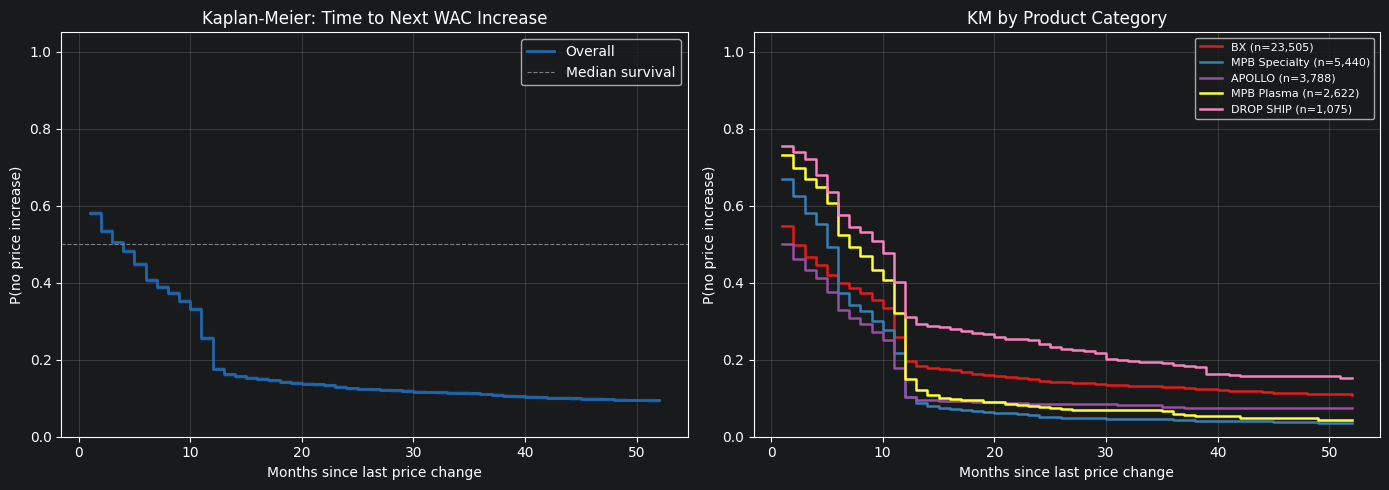

Median time to next price increase: ~4 months


In [3]:
# ── Kaplan-Meier Survival Curve ──
# Shows P(no price increase) over time across the full population and by product category.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall KM
time_km, surv_km, conf_int = kaplan_meier_estimator(
    surv_df["event"], surv_df["duration_months"], conf_type="log-log"
)
ax = axes[0]
ax.step(time_km, surv_km, where="post", color="#2166AC", linewidth=2, label="Overall")
ax.fill_between(time_km, conf_int[0], conf_int[1], step="post", alpha=0.2, color="#2166AC")
ax.set_xlabel("Months since last price change")
ax.set_ylabel("P(no price increase)")
ax.set_title("Kaplan-Meier: Time to Next WAC Increase")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Median survival")
ax.legend()

# By product category (top 5 by count)
top_cats = surv_df["CUST_PROD_CATEGORY"].value_counts().head(5).index
colors = plt.cm.Set1(np.linspace(0, 0.8, 5))
ax2 = axes[1]
for cat, col in zip(top_cats, colors):
    sub = surv_df[surv_df["CUST_PROD_CATEGORY"] == cat]
    t, s, _ = kaplan_meier_estimator(sub["event"], sub["duration_months"], conf_type="log-log")
    ax2.step(t, s, where="post", linewidth=1.8, label=f"{cat} (n={len(sub):,})", color=col)
ax2.set_xlabel("Months since last price change")
ax2.set_ylabel("P(no price increase)")
ax2.set_title("KM by Product Category")
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Median survival time overall
median_idx = np.searchsorted(-surv_km, -0.5)
print(f"Median time to next price increase: ~{time_km[min(median_idx, len(time_km)-1)]:.0f} months")


In [4]:
# ── Feature Engineering & Train/Val Split ──

le_cat  = LabelEncoder()
le_mfr  = LabelEncoder()

feat_df = surv_df.copy()
feat_df["CUST_PROD_CATEGORY_enc"] = le_cat.fit_transform(feat_df["CUST_PROD_CATEGORY"].fillna("UNKNOWN"))
feat_df["MANUFACTURER_NAME_enc"]  = le_mfr.fit_transform(feat_df["MANUFACTURER_NAME"].fillna("UNKNOWN"))
feat_df["THERAPEUTIC_CLASS"]      = pd.to_numeric(feat_df["THERAPEUTIC_CLASS"], errors="coerce").fillna(-1)
feat_df["LOE_YEAR"]               = feat_df["LOE_YEAR"].fillna(-1)
feat_df["log_wac"]                = np.log1p(feat_df["BASELINE_WAC_PRICE"].clip(lower=0))
feat_df["log_revenue"]            = np.log1p(feat_df["NET_REVENUE"].clip(lower=0))

FEATURES = [
    # Structural / identity features
    "log_wac",
    "log_revenue",
    "CUMUL_REV_PCT",
    "n_prior_changes",
    "CUST_PROD_CATEGORY_enc",
    "THERAPEUTIC_CLASS",
    "MANUFACTURER_NAME_enc",
    "LOE_YEAR",
    # Historical price-change pattern features
    "time_since_last_increase",
    "num_increases_last_24m",
    "increase_spell_length",
    "month",
    "jan_jul_indicator",
    "prior_pct_increase",
    "rolling_avg_increase_36m",
    "max_increase_last_3yrs",
    "compound_increase_rate",
    "has_increased_every_year_last_3yrs",
    "increase_volatility_low_flag",
]

X = feat_df[FEATURES].fillna(0).values.astype(float)
# sksurv requires structured array: (event: bool, duration: float)
y = np.array(
    [(bool(e), float(d)) for e, d in zip(feat_df["event"], feat_df["duration_months"])],
    dtype=[("event", bool), ("duration", float)]
)

# Temporal split — train on spells starting before 2024, validate on 2024+
# Mirrors tree/long-horizon notebooks: only 2022-2023 data available at training time.
TRAIN_CUTOFF = pd.Timestamp("2024-01-01")
train_mask = feat_df["SPELL_START_DATE"] < TRAIN_CUTOFF
val_mask   = feat_df["SPELL_START_DATE"] >= TRAIN_CUTOFF

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print(f"Train: {len(X_train):,} spells (spells starting < 2024)")
print(f"Val  : {len(X_val):,} spells (spells starting >= 2024)")
print(f"Train event rate: {y_train['event'].mean():.1%} | Val event rate: {y_val['event'].mean():.1%}")
print(f"Features: {FEATURES}")


Train: 18,134 spells (spells starting < 2024)
Val  : 19,258 spells (spells starting >= 2024)
Train event rate: 88.6% | Val event rate: 74.7%
Features: ['log_wac', 'log_revenue', 'CUMUL_REV_PCT', 'n_prior_changes', 'CUST_PROD_CATEGORY_enc', 'THERAPEUTIC_CLASS', 'MANUFACTURER_NAME_enc', 'LOE_YEAR', 'time_since_last_increase', 'num_increases_last_24m', 'increase_spell_length', 'month', 'jan_jul_indicator', 'prior_pct_increase', 'rolling_avg_increase_36m', 'max_increase_last_3yrs', 'compound_increase_rate', 'has_increased_every_year_last_3yrs', 'increase_volatility_low_flag']


Cox PH — C-index: 0.6750

Cox coefficients (positive = higher hazard = shorter time to increase):
                           Feature          Coef
                   n_prior_changes  5.019568e-01
      increase_volatility_low_flag  3.902908e-01
                 jan_jul_indicator  1.900839e-01
                       log_revenue  1.177082e-01
          time_since_last_increase  1.542784e-02
             increase_spell_length  1.542784e-02
            CUST_PROD_CATEGORY_enc  1.330325e-02
            max_increase_last_3yrs  2.680442e-03
          rolling_avg_increase_36m  2.002535e-03
                          LOE_YEAR  7.811773e-05
                 THERAPEUTIC_CLASS  1.964570e-07
            compound_increase_rate  0.000000e+00
             MANUFACTURER_NAME_enc -2.768540e-04
                prior_pct_increase -1.603627e-03
                           log_wac -1.662108e-02
                             month -2.406890e-02
has_increased_every_year_last_3yrs -4.192267e-01
            num_incr

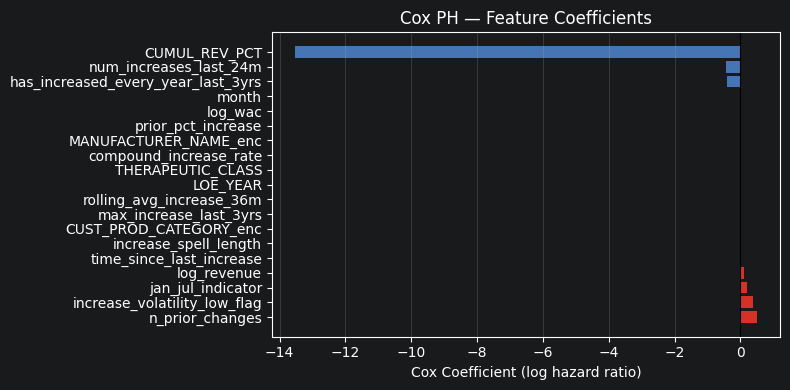

In [5]:
# ── Cox Proportional Hazards Model ──
cox = CoxPHSurvivalAnalysis(alpha=0.01, ties="efron")
cox.fit(X_train, y_train)

cox_ci = concordance_index_censored(y_val["event"], y_val["duration"], cox.predict(X_val))
print(f"Cox PH — C-index: {cox_ci[0]:.4f}")

# Coefficients
coef_df = pd.DataFrame({"Feature": FEATURES, "Coef": cox.coef_}).sort_values("Coef", ascending=False)
print("\nCox coefficients (positive = higher hazard = shorter time to increase):")
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d73027" if c > 0 else "#4575b4" for c in coef_df["Coef"]]
ax.barh(coef_df["Feature"], coef_df["Coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cox Coefficient (log hazard ratio)")
ax.set_title("Cox PH — Feature Coefficients")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


Random Survival Forest — C-index: 0.7169
Permutation feature importances (drop in C-index):
                           Feature  Importance
            num_increases_last_24m    0.012490
                prior_pct_increase    0.009480
                   n_prior_changes    0.007576
          rolling_avg_increase_36m    0.007346
                     CUMUL_REV_PCT    0.004370
                       log_revenue    0.003920
      increase_volatility_low_flag    0.002232
          time_since_last_increase    0.001269
             increase_spell_length    0.000861
                 THERAPEUTIC_CLASS    0.000770
             MANUFACTURER_NAME_enc    0.000662
has_increased_every_year_last_3yrs    0.000642
                          LOE_YEAR    0.000544
                           log_wac    0.000393
            CUST_PROD_CATEGORY_enc    0.000174
            compound_increase_rate    0.000000
            max_increase_last_3yrs   -0.000090
                 jan_jul_indicator   -0.000872
               

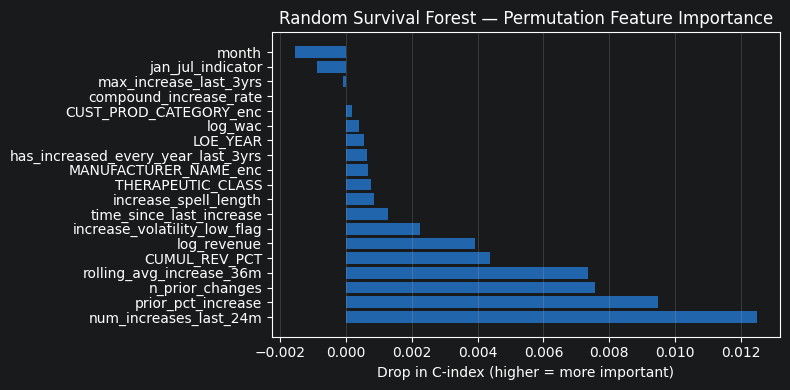

In [6]:
# ── Random Survival Forest ──
rsf = RandomSurvivalForest(
    n_estimators=200, max_depth=6, min_samples_leaf=15,
    max_features="sqrt", n_jobs=-1, random_state=42
)
rsf.fit(X_train, y_train)

rsf_ci = concordance_index_censored(y_val["event"], y_val["duration"], rsf.predict(X_val))
print(f"Random Survival Forest — C-index: {rsf_ci[0]:.4f}")

# scikit-survival RSF does not expose feature_importances_; use permutation importance instead
from sklearn.inspection import permutation_importance

def rsf_scorer(model, X, y):
    pred = model.predict(X)
    return concordance_index_censored(y["event"], y["duration"], pred)[0]

perm = permutation_importance(rsf, X_val, y_val, scoring=rsf_scorer, n_repeats=10, random_state=42, n_jobs=-1)
fi = pd.DataFrame({"Feature": FEATURES, "Importance": perm.importances_mean}).sort_values("Importance", ascending=False)
print("Permutation feature importances (drop in C-index):")
print(fi.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(fi["Feature"], fi["Importance"], color="#2166AC")
ax.set_xlabel("Drop in C-index (higher = more important)")
ax.set_title("Random Survival Forest — Permutation Feature Importance")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


In [7]:
# ── Gradient Boosting Survival Analysis ──
gbts = GradientBoostingSurvivalAnalysis(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    min_samples_leaf=30, subsample=0.7, random_state=42
)
gbts.fit(X_train, y_train)

gbts_ci = concordance_index_censored(y_val["event"], y_val["duration"], gbts.predict(X_val))
print(f"GBT Survival — C-index: {gbts_ci[0]:.4f}")

# ── Summary ──
print("\n" + "="*45)
print(f"{'Model':<30} {'C-index':>10}")
print("="*45)
print(f"{'Cox PH':<30} {cox_ci[0]:>10.4f}")
print(f"{'Random Survival Forest':<30} {rsf_ci[0]:>10.4f}")
print(f"{'GBT Survival':<30} {gbts_ci[0]:>10.4f}")
print("="*45)
print("C-index: 0.5 = random, 1.0 = perfect ranking of who increases next")


GBT Survival — C-index: 0.7403

Model                             C-index
Cox PH                             0.6750
Random Survival Forest             0.7169
GBT Survival                       0.7403
C-index: 0.5 = random, 1.0 = perfect ranking of who increases next


GBT Magnitude Regressor — WAC % Change Prediction
  Validation MAE      : 2.80%  (vs raw targets)
  Validation Median AE: 0.96%  (vs raw targets)
  Validation R²       : 0.0737  (on winsorized [-26.8%, 18.7%] scale)
  Training spells     : 24,390  |  Val spells: 6,098
  Raw target range    : -100.0% to 2575.7%  (mean 1.98%)
  Winsorized range    : -26.8% to 18.7%


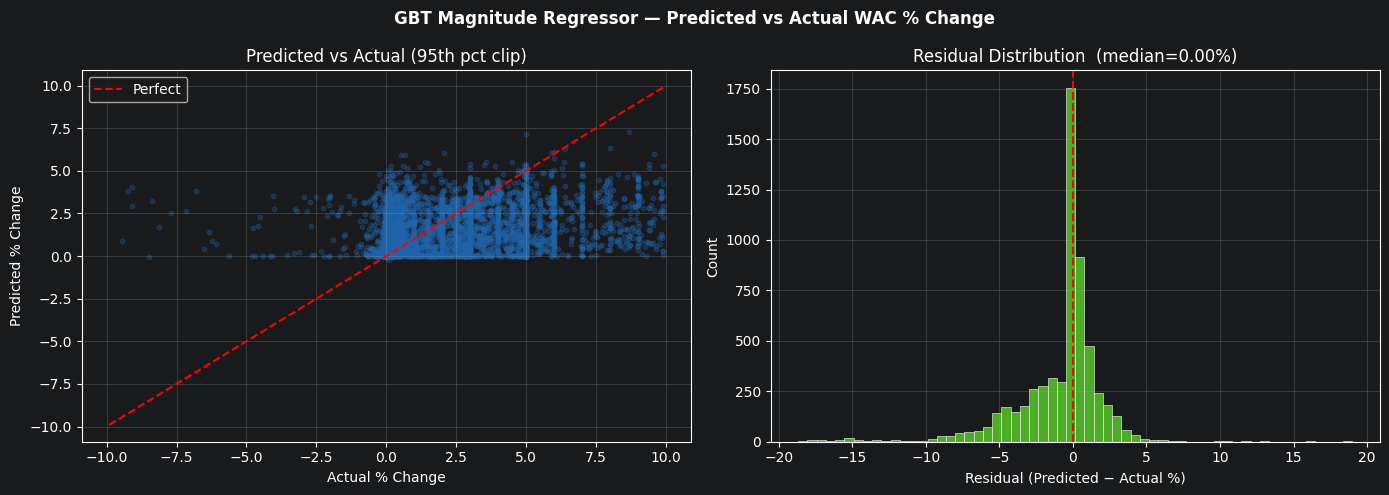


Permutation feature importances (increase in MAE when shuffled):
        Feature  Importance
        log_rev    0.329399
        cat_enc    0.142995
        mfr_enc    0.129570
        log_wac    0.119683
             tc    0.077668
       LOE_YEAR    0.008569
  CUMUL_REV_PCT    0.001432
n_prior_changes    0.000000


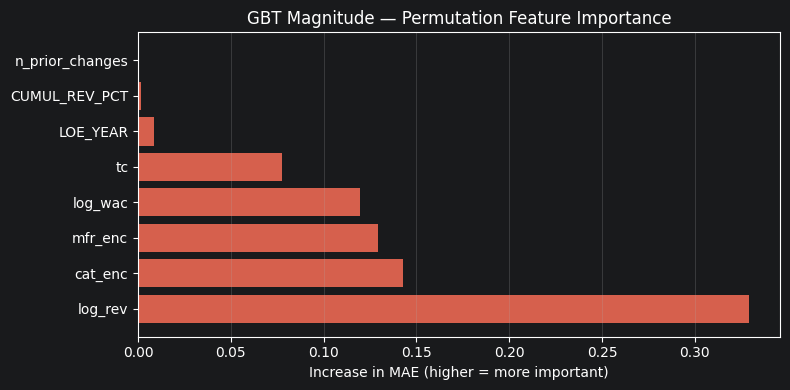

In [8]:
# ── GBT Regressor: Magnitude of Next WAC Price Change ──
# Survival model tells us WHEN a change happens; this tells us HOW MUCH.
# Target: % change from spell-start WAC to the next observed WAC price.
# Trained only on event=True spells (censored spells have no observed outcome).

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

# ── Rebuild spells with magnitude target ──
# Re-aggregate COPA to one row per (material, date) then compute change at each price event.
copa_raw = pd.read_csv(
    "/Users/vishnu.gorur/PycharmProjects/JupyterProject/data/real_data/No_leakage_Active_COPA_data.csv"
)
copa_raw["WAC_PRICE_COPA_DATE"] = pd.to_datetime(copa_raw["WAC_PRICE_COPA_DATE"])
copa_m2 = (copa_raw.groupby(["COPA_MTRL_NUM", "WAC_PRICE_COPA_DATE"])
           .agg(BASELINE_WAC_PRICE=("BASELINE_WAC_PRICE", "min"))
           .reset_index()
           .sort_values(["COPA_MTRL_NUM", "WAC_PRICE_COPA_DATE"]))
copa_m2["_price_changed"] = (copa_m2.groupby("COPA_MTRL_NUM")["BASELINE_WAC_PRICE"]
                               .transform(lambda x: x.ne(x.shift()).astype(int)))
copa_m2.loc[copa_m2.groupby("COPA_MTRL_NUM").head(1).index, "_price_changed"] = 0

mag_records = []
for mtrl, grp in copa_m2.groupby("COPA_MTRL_NUM"):
    grp = grp.reset_index(drop=True)
    change_idx = grp.index[grp["_price_changed"] == 1].tolist()
    for s_idx, e_idx in zip([0] + change_idx, change_idx + [None]):
        if e_idx is None:
            continue  # censored — no observed magnitude
        start_wac = grp.iloc[s_idx]["BASELINE_WAC_PRICE"]
        end_wac   = grp.iloc[e_idx]["BASELINE_WAC_PRICE"]
        if start_wac <= 0:
            continue
        change_pct = (end_wac - start_wac) / start_wac * 100
        mag_records.append({"COPA_MTRL_NUM": mtrl, "CHANGE_PCT": change_pct, "EVENT_DATE": grp.iloc[e_idx]["WAC_PRICE_COPA_DATE"]})

mag_df = pd.DataFrame(mag_records)

# Merge features from surv_df (already has TC, manufacturer, LOE, etc.)
# Use one representative row per material (spell-level features)
surv_event = surv_df[surv_df["event"]].drop_duplicates("COPA_MTRL_NUM").copy()
mag_df = mag_df.merge(
    surv_event.drop(columns=["event", "duration_months"]),
    on="COPA_MTRL_NUM", how="left"
)

# Encode categoricals
le_cat2 = LabelEncoder()
le_mfr2 = LabelEncoder()
mag_df["cat_enc"]  = le_cat2.fit_transform(mag_df["CUST_PROD_CATEGORY"].fillna("UNKNOWN"))
mag_df["mfr_enc"]  = le_mfr2.fit_transform(mag_df["MANUFACTURER_NAME"].fillna("UNKNOWN"))
mag_df["tc"]       = pd.to_numeric(mag_df["THERAPEUTIC_CLASS"], errors="coerce").fillna(-1)
mag_df["log_wac"]  = np.log1p(mag_df["BASELINE_WAC_PRICE"].clip(lower=0))
mag_df["log_rev"]  = np.log1p(mag_df["NET_REVENUE"].clip(lower=0))

MAG_FEATURES = ["log_wac", "log_rev", "CUMUL_REV_PCT", "n_prior_changes",
                "cat_enc", "tc", "mfr_enc", "LOE_YEAR"]

mag_clean = mag_df.dropna(subset=["CHANGE_PCT"]).copy()
X_mag = mag_clean[MAG_FEATURES].fillna(0).values
y_mag = mag_clean["CHANGE_PCT"].values

# Temporal split — train < 2024, val 2024+ — preserves time ordering
train_mask = mag_clean["EVENT_DATE"] < "2024-01-01"
val_mask   = ~train_mask

# Winsorize target at 1st/99th percentile — extreme IRA/structural breaks
# dominate squared loss and push R² negative. Huber loss further dampens outliers.
p1, p99 = np.percentile(y_mag, [1, 99])
y_mag_clip = np.clip(y_mag, p1, p99)

X_tr_m  = mag_clean.loc[train_mask, MAG_FEATURES].fillna(0).values
X_v_m   = mag_clean.loc[val_mask,   MAG_FEATURES].fillna(0).values
y_tr_m  = y_mag_clip[train_mask.values]
y_v_m   = y_mag_clip[val_mask.values]
y_v_raw = y_mag[val_mask.values]

gbt_mag = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05, max_depth=5,
    min_samples_leaf=20, l2_regularization=1.0,
    loss="absolute_error",   # MAE loss — robust to remaining outliers
    random_state=42
)
gbt_mag.fit(X_tr_m, y_tr_m)
preds       = gbt_mag.predict(X_v_m)

mae   = mean_absolute_error(y_v_raw, preds)
medae = median_absolute_error(y_v_raw, preds)
r2    = r2_score(y_v_m, preds)   # R² on winsorized scale

print(f"GBT Magnitude Regressor — WAC % Change Prediction")
print(f"  Validation MAE      : {mae:.2f}%  (vs raw targets)")
print(f"  Validation Median AE: {medae:.2f}%  (vs raw targets)")
print(f"  Validation R²       : {r2:.4f}  (on winsorized [{p1:.1f}%, {p99:.1f}%] scale)")
print(f"  Training spells     : {len(X_tr_m):,}  |  Val spells: {len(X_v_m):,}")
print(f"  Raw target range    : {y_mag.min():.1f}% to {y_mag.max():.1f}%  (mean {y_mag.mean():.2f}%)")
print(f"  Winsorized range    : {p1:.1f}% to {p99:.1f}%")

# ── Predicted vs actual scatter + residual distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GBT Magnitude Regressor — Predicted vs Actual WAC % Change", fontweight="bold")

clip = np.percentile(np.abs(y_v_m), 95)
mask = np.abs(y_v_m) <= clip
axes[0].scatter(y_v_m[mask], preds[mask], alpha=0.3, s=10, color="#2166AC")
lim = max(abs(y_v_m[mask]).max(), abs(preds[mask]).max())
axes[0].plot([-lim, lim], [-lim, lim], "r--", linewidth=1.5, label="Perfect")
axes[0].set_xlabel("Actual % Change"); axes[0].set_ylabel("Predicted % Change")
axes[0].set_title("Predicted vs Actual (95th pct clip)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

residuals = preds - y_v_m
axes[1].hist(residuals[np.abs(residuals) <= clip * 2], bins=60, color="#4DAC26",
             edgecolor="white", linewidth=0.4)
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Residual (Predicted − Actual %)"); axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution  (median={np.median(residuals):.2f}%)")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Feature importance via permutation (HistGBT has no feature_importances_) ──
from sklearn.inspection import permutation_importance

perm_mag = permutation_importance(gbt_mag, X_v_m, y_v_m, n_repeats=10,
                                   scoring="neg_mean_absolute_error",
                                   random_state=42, n_jobs=-1)
fi_mag = (pd.DataFrame({"Feature": MAG_FEATURES, "Importance": perm_mag.importances_mean})
            .sort_values("Importance", ascending=False))
print("\nPermutation feature importances (increase in MAE when shuffled):")
print(fi_mag.to_string(index=False))

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.barh(fi_mag["Feature"], fi_mag["Importance"], color="#D6604D")
ax2.set_xlabel("Increase in MAE (higher = more important)")
ax2.set_title("GBT Magnitude — Permutation Feature Importance")
ax2.grid(True, alpha=0.3, axis="x")
plt.tight_layout(); plt.show()


  BACKTEST SUMMARY — 2024+ Validation Spells

  Timing (months until next price change):
    MAE         : 3.2 months
    Median AE   : 2.0 months
    Spells      : 14,391 observed events

  Magnitude (dollar WAPE on WAC change):
    Dollar WAPE : 70.79%
    Spells      : 28,756 observed events


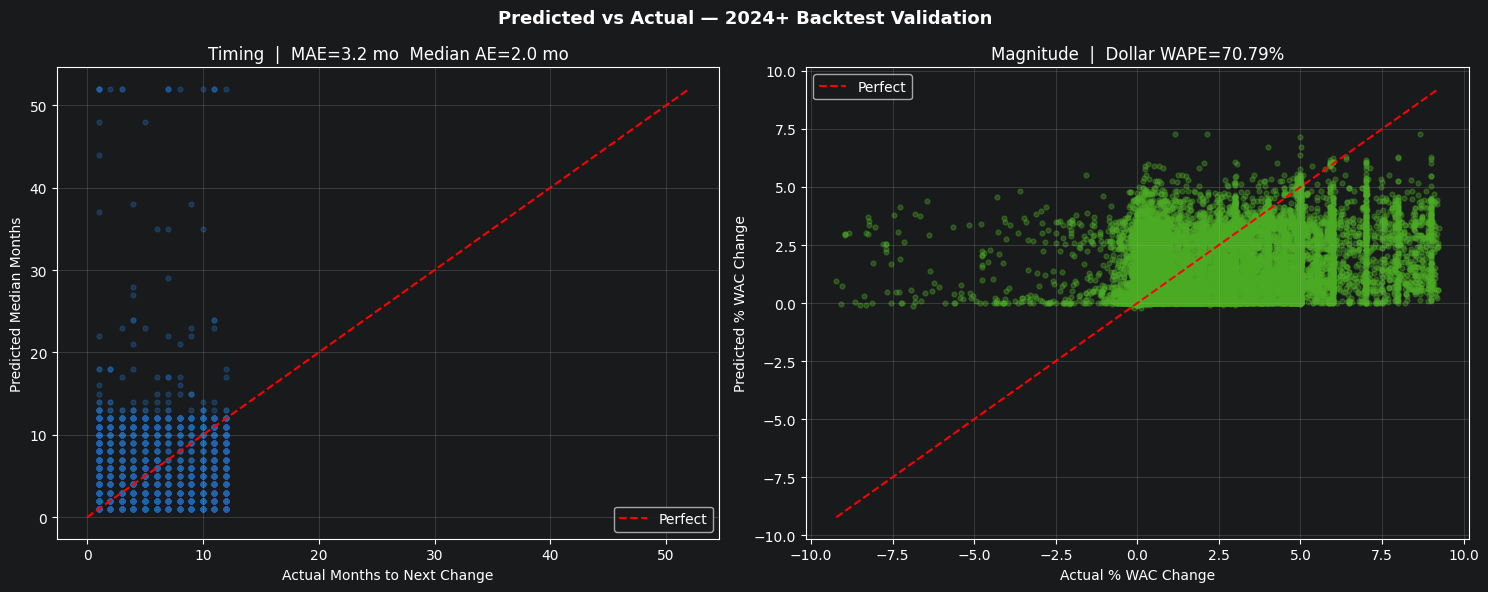


  Timing prediction accuracy buckets (event=True val spells):
    Within  1 month(s): 43.0%
    Within  2 month(s): 53.4%
    Within  3 month(s): 61.7%
    Within  6 month(s): 84.1%
    Within 12 month(s): 99.2%

  Magnitude prediction accuracy buckets:
    Within  1%: 52.4%
    Within  2%: 69.1%
    Within  5%: 91.4%
    Within 10%: 97.4%

  Magnitude — TOP-500 PRODUCTS ONLY (6,081 val spells):
    Dollar WAPE : 85.84%
  Accuracy buckets (% change):
    Within  1%: 69.5%
    Within  2%: 80.6%
    Within  5%: 96.3%
    Within 10%: 99.2%


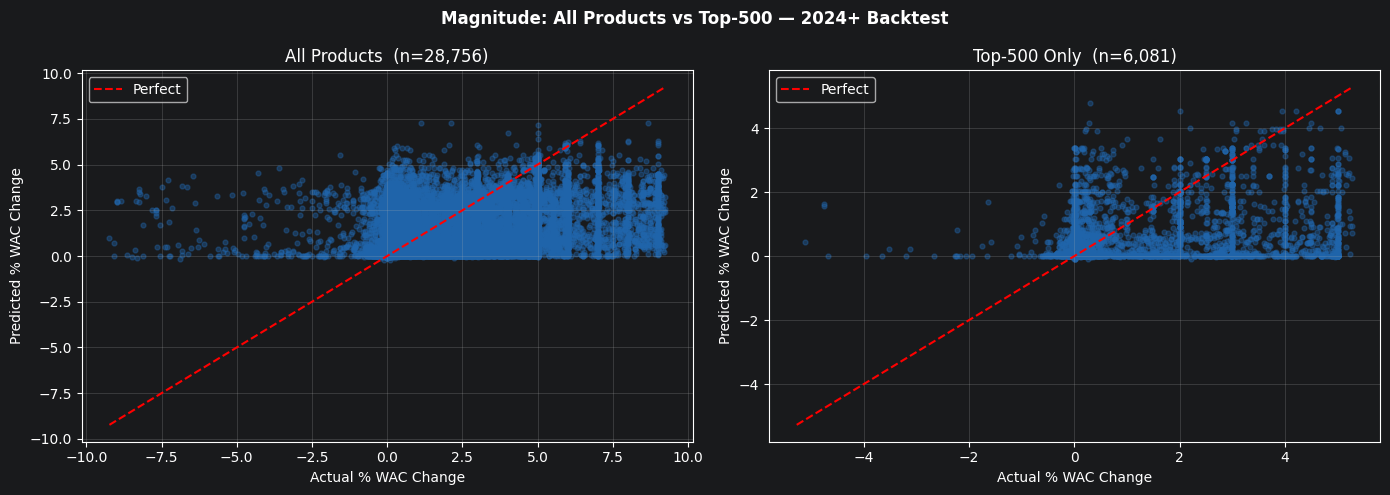

In [9]:
# ── Predicted vs Actual: Timing and Magnitude ──
# For the validation set (2024+ spells), compare:
#   1. Predicted median time-to-change vs actual duration (survival model)
#   2. Predicted % change vs actual % change (magnitude regressor)
# Only event=True spells have a known outcome for both comparisons.

# ── 1. Extract predicted median time-to-change from GBT survival curves ──
# predict_survival_function returns S(t) per sample.
# Predicted median = first t where S(t) drops below 0.5.
surv_fns = gbts.predict_survival_function(X_val)

pred_median_time = []
for fn in surv_fns:
    times  = fn.x
    surv   = fn(times)
    # Find first time where survival drops below 0.5
    below  = np.where(surv <= 0.5)[0]
    pred_median_time.append(float(times[below[0]]) if len(below) > 0 else float(times[-1]))

pred_median_time = np.array(pred_median_time)
actual_duration  = y_val["duration"]
actual_event     = y_val["event"]

# Only compare on spells where the change was actually observed (event=True)
obs_mask = actual_event
pred_t   = pred_median_time[obs_mask]
act_t    = actual_duration[obs_mask]

timing_mae   = np.mean(np.abs(pred_t - act_t))
timing_medae = np.median(np.abs(pred_t - act_t))

# ── 2. Predicted vs actual magnitude on the val set ──
# mag_clean was built from all spells; filter to val period (SPELL_START_DATE >= 2024)
mag_val = mag_clean[mag_clean["COPA_MTRL_NUM"].isin(
    surv_df[val_mask]["COPA_MTRL_NUM"]
)].copy()

X_mag_val = mag_val[MAG_FEATURES].fillna(0).values
pred_pct   = gbt_mag.predict(X_mag_val)
act_pct    = mag_val["CHANGE_PCT"].values

# Dollar WAPE: weighted by actual dollar change magnitude
# actual_$ = act_pct/100 * WAC_price;  pred_$ = pred_pct/100 * WAC_price
wac_val_mag  = mag_val["BASELINE_WAC_PRICE"].values
act_dollar   = act_pct  / 100 * wac_val_mag
pred_dollar  = pred_pct / 100 * wac_val_mag
mag_wape     = np.sum(np.abs(act_dollar - pred_dollar)) / (np.sum(np.abs(act_dollar)) + 1e-9) * 100

# ── Print summary ──
print("=" * 55)
print("  BACKTEST SUMMARY — 2024+ Validation Spells")
print("=" * 55)
print(f"\n  Timing (months until next price change):")
print(f"    MAE         : {timing_mae:.1f} months")
print(f"    Median AE   : {timing_medae:.1f} months")
print(f"    Spells      : {obs_mask.sum():,} observed events")
print(f"\n  Magnitude (dollar WAPE on WAC change):")
print(f"    Dollar WAPE : {mag_wape:.2f}%")
print(f"    Spells      : {len(act_pct):,} observed events")
print("=" * 55)

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Predicted vs Actual — 2024+ Backtest Validation", fontweight="bold", fontsize=13)

# ── Left: Timing ──
ax = axes[0]
clip_t = np.percentile(act_t, 95)
m = act_t <= clip_t
ax.scatter(act_t[m], pred_t[m], alpha=0.35, s=12, color="#2166AC")
lim = max(act_t[m].max(), pred_t[m].max())
ax.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect")
ax.set_xlabel("Actual Months to Next Change")
ax.set_ylabel("Predicted Median Months")
ax.set_title(f"Timing  |  MAE={timing_mae:.1f} mo  Median AE={timing_medae:.1f} mo")
ax.legend(); ax.grid(True, alpha=0.3)

# ── Right: Magnitude ──
ax = axes[1]
clip_m = np.percentile(np.abs(act_pct), 95)
m2 = np.abs(act_pct) <= clip_m
ax.scatter(act_pct[m2], pred_pct[m2], alpha=0.35, s=12, color="#4DAC26")
lim2 = max(np.abs(act_pct[m2]).max(), np.abs(pred_pct[m2]).max())
ax.plot([-lim2, lim2], [-lim2, lim2], "r--", linewidth=1.5, label="Perfect")
ax.set_xlabel("Actual % WAC Change")
ax.set_ylabel("Predicted % WAC Change")
ax.set_title(f"Magnitude  |  Dollar WAPE={mag_wape:.2f}%")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── Error distribution by bucket ──
# How often does the timing prediction land within N months?
print("\n  Timing prediction accuracy buckets (event=True val spells):")
for thr in [1, 2, 3, 6, 12]:
    pct = np.mean(np.abs(pred_t - act_t) <= thr) * 100
    print(f"    Within {thr:2d} month(s): {pct:.1f}%")

print("\n  Magnitude prediction accuracy buckets:")
for thr in [1, 2, 5, 10]:
    pct = np.mean(np.abs(pred_pct - act_pct) <= thr) * 100
    print(f"    Within {thr:2d}%: {pct:.1f}%")

# ── Top-500 filter ──
# Load top-500 MTRLs and restrict magnitude evaluation to those only
import openpyxl
loe_wb   = openpyxl.load_workbook(
    "/Users/vishnu.gorur/PycharmProjects/JupyterProject/data/real_data/Top_500_Revenue_Materials_BT_05292026_v1.xlsx",
    read_only=True, data_only=True)
top_ws   = loe_wb["Top_Revenue_Products"]
top_rows = list(top_ws.values)
top_df   = pd.DataFrame(top_rows[1:], columns=top_rows[0])
top_mtrls = set(top_df["MTRL_NUM"].astype(str).str.zfill(18).dropna())

mag_val_top500 = mag_val[
    mag_val["COPA_MTRL_NUM"].astype(str).str.zfill(18).isin(top_mtrls)
].copy()

if len(mag_val_top500) == 0:
    print("\n  [!] No top-500 matches in val set — check MTRL_NUM format")
else:
    X_mag_top = mag_val_top500[MAG_FEATURES].fillna(0).values
    pred_pct_top = gbt_mag.predict(X_mag_top)
    act_pct_top  = mag_val_top500["CHANGE_PCT"].values

    wac_top       = mag_val_top500["BASELINE_WAC_PRICE"].values
    act_dol_top   = act_pct_top  / 100 * wac_top
    pred_dol_top  = pred_pct_top / 100 * wac_top
    wape_top      = np.sum(np.abs(act_dol_top - pred_dol_top)) / (np.sum(np.abs(act_dol_top)) + 1e-9) * 100

    print(f"\n  Magnitude — TOP-500 PRODUCTS ONLY ({len(mag_val_top500):,} val spells):")
    print(f"    Dollar WAPE : {wape_top:.2f}%")
    print(f"  Accuracy buckets (% change):")
    for thr in [1, 2, 5, 10]:
        pct = np.mean(np.abs(pred_pct_top - act_pct_top) <= thr) * 100
        print(f"    Within {thr:2d}%: {pct:.1f}%")

    # Side-by-side scatter: all vs top-500
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    fig2.suptitle("Magnitude: All Products vs Top-500 — 2024+ Backtest", fontweight="bold")
    for ax, act, pred, title in [
        (axes2[0], act_pct,     pred_pct,     f"All Products  (n={len(act_pct):,})"),
        (axes2[1], act_pct_top, pred_pct_top, f"Top-500 Only  (n={len(act_pct_top):,})"),
    ]:
        clip = np.percentile(np.abs(act), 95)
        m    = np.abs(act) <= clip
        ax.scatter(act[m], pred[m], alpha=0.4, s=12, color="#2166AC")
        lim  = max(np.abs(act[m]).max(), np.abs(pred[m]).max())
        ax.plot([-lim, lim], [-lim, lim], "r--", linewidth=1.5, label="Perfect")
        ax.set_xlabel("Actual % WAC Change"); ax.set_ylabel("Predicted % WAC Change")
        ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


In [10]:
# ── Rolling Refit Backtest Helper ──
# Simulates production: retrain on all data up to cutoff, evaluate on next window.
# Used by both quarterly and semi-annual cells below.

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error

def build_and_encode(spells_df, le_cat_fit=None, le_mfr_fit=None):
    df = spells_df.copy()
    if le_cat_fit is None:
        le_cat_fit = LabelEncoder().fit(df["CUST_PROD_CATEGORY"].fillna("UNKNOWN"))
    if le_mfr_fit is None:
        le_mfr_fit = LabelEncoder().fit(df["MANUFACTURER_NAME"].fillna("UNKNOWN"))
    df["CUST_PROD_CATEGORY_enc"] = df["CUST_PROD_CATEGORY"].fillna("UNKNOWN").apply(
        lambda x: le_cat_fit.transform([x])[0] if x in le_cat_fit.classes_ else 0)
    df["MANUFACTURER_NAME_enc"]  = df["MANUFACTURER_NAME"].fillna("UNKNOWN").apply(
        lambda x: le_mfr_fit.transform([x])[0] if x in le_mfr_fit.classes_ else 0)
    df["THERAPEUTIC_CLASS"]      = pd.to_numeric(df["THERAPEUTIC_CLASS"], errors="coerce").fillna(-1)
    df["LOE_YEAR"]               = df["LOE_YEAR"].fillna(-1)
    df["log_wac"]                = np.log1p(df["BASELINE_WAC_PRICE"].clip(lower=0))
    df["log_revenue"]            = np.log1p(df["NET_REVENUE"].clip(lower=0))
    X = df[FEATURES].fillna(0).values.astype(float)
    # Build y only if event/duration columns exist (mag dfs may not have them)
    if "event" in df.columns and "duration_months" in df.columns:
        y = np.array([(bool(e), float(d)) for e, d in zip(df["event"], df["duration_months"])],
                     dtype=[("event", bool), ("duration", float)])
    else:
        y = None
    return X, y, le_cat_fit, le_mfr_fit, df


MAG_FEATURES_W = [
    "log_wac", "log_revenue", "CUMUL_REV_PCT", "n_prior_changes",
    "CUST_PROD_CATEGORY_enc", "THERAPEUTIC_CLASS", "MANUFACTURER_NAME_enc", "LOE_YEAR",
    "time_since_last_increase", "num_increases_last_24m", "prior_pct_increase",
    "rolling_avg_increase_36m", "jan_jul_indicator",
]


def run_window(train_spells, val_spells, label, val_end=None):
    if len(train_spells) < 100 or len(val_spells) < 5:
        return None

    X_tr, y_tr, le_cat_w, le_mfr_w, _ = build_and_encode(train_spells)
    X_v,  y_v,  _,        _,        val_enc = build_and_encode(val_spells, le_cat_w, le_mfr_w)

    # Survival model
    gbts_w = GradientBoostingSurvivalAnalysis(
        n_estimators=100, learning_rate=0.1, max_depth=3,
        min_samples_leaf=30, subsample=0.7, random_state=42)
    gbts_w.fit(X_tr, y_tr)
    ci = concordance_index_censored(y_v["event"], y_v["duration"], gbts_w.predict(X_v))[0]

    # Timing MAE on observed events only
    obs_mask  = y_v["event"]
    surv_fns  = gbts_w.predict_survival_function(X_v[obs_mask])
    pred_t    = []
    for fn in surv_fns:
        below = np.where(fn(fn.x) <= 0.5)[0]
        pred_t.append(float(fn.x[below[0]]) if len(below) > 0 else float(fn.x[-1]))
    pred_t  = np.array(pred_t)
    act_t   = y_v["duration"][obs_mask]
    t_mae   = float(np.mean(np.abs(pred_t - act_t)))
    t_med   = float(np.median(np.abs(pred_t - act_t)))
    w3m     = float(np.mean(np.abs(pred_t - act_t) <= 3) * 100)

    # Magnitude regressor — compute CHANGE_PCT from copa_m2 for both train and val
    def get_mag_df(spells, copa_subset):
        copa_sub = copa_subset.copy()
        copa_sub["_pc"] = copa_sub.groupby("COPA_MTRL_NUM")["BASELINE_WAC_PRICE"].transform(
            lambda x: x.ne(x.shift()).astype(int))
        recs = []
        for mtrl, grp in copa_sub.groupby("COPA_MTRL_NUM"):
            grp = grp.reset_index(drop=True)
            cidx = grp.index[grp["_pc"] == 1].tolist()
            for si, ei in zip([0] + cidx, cidx + [None]):
                if ei is None: continue
                sw = grp.iloc[si]["BASELINE_WAC_PRICE"]
                ew = grp.iloc[ei]["BASELINE_WAC_PRICE"]
                if sw > 0:
                    recs.append({"COPA_MTRL_NUM": mtrl,
                                 "CHANGE_PCT": (ew - sw) / sw * 100})
        mag = pd.DataFrame(recs).merge(
            spells.drop_duplicates("COPA_MTRL_NUM"), on="COPA_MTRL_NUM", how="inner")
        return mag.dropna(subset=["CHANGE_PCT", "CUST_PROD_CATEGORY"])

    # Training magnitude targets: copa_m2 rows before train cutoff
    tr_cutoff = train_spells["SPELL_START_DATE"].max()
    mag_tr_df = get_mag_df(train_spells,
                           copa_m2[copa_m2["WAC_PRICE_COPA_DATE"] < tr_cutoff])

    # Val magnitude targets: copa_m2 rows in val window (event spells only)
    val_event_spells = val_spells[val_spells["event"]].copy()
    val_cutoff_start = val_spells["SPELL_START_DATE"].min()
    # Cap outcome window at val_end to avoid leaking post-window changes (e.g. 2026 IRA drops)
    val_cutoff_end = pd.Timestamp(val_end) if val_end else val_spells["SPELL_START_DATE"].max() + pd.DateOffset(months=13)
    mag_val_df = get_mag_df(val_event_spells,
                            copa_m2[(copa_m2["WAC_PRICE_COPA_DATE"] >= val_cutoff_start) &
                                    (copa_m2["WAC_PRICE_COPA_DATE"] <  val_cutoff_end)])

    if len(mag_tr_df) < 20 or len(mag_val_df) < 5:
        m_mae = m_med = w1 = w2 = float("nan")
    else:
        # Encode features for magnitude dfs using same encoders
        _, _, _, _, mag_tr_enc  = build_and_encode(mag_tr_df,  le_cat_w, le_mfr_w)
        _, _, _, _, mag_val_enc = build_and_encode(mag_val_df, le_cat_w, le_mfr_w)

        y_mag_tr = mag_tr_enc["CHANGE_PCT"].values
        p1, p99  = np.percentile(y_mag_tr, [1, 99])
        y_clip   = np.clip(y_mag_tr, p1, p99)
        X_mag_tr = mag_tr_enc[MAG_FEATURES_W].fillna(0).values
        X_mag_v  = mag_val_enc[MAG_FEATURES_W].fillna(0).values
        act_m    = mag_val_enc["CHANGE_PCT"].values

        gbt_m = HistGradientBoostingRegressor(
            max_iter=200, learning_rate=0.05, max_depth=4,
            min_samples_leaf=20, loss="absolute_error", random_state=42)
        gbt_m.fit(X_mag_tr, y_clip)
        preds_m = gbt_m.predict(X_mag_v)

        wac_m  = mag_val_enc["BASELINE_WAC_PRICE"].values
        act_d  = act_m   / 100 * wac_m
        pred_d = preds_m / 100 * wac_m
        m_wape = float(np.sum(np.abs(act_d - pred_d)) / (np.sum(np.abs(act_d)) + 1e-9) * 100)
        w1     = float(np.mean(np.abs(preds_m - act_m) <= 1) * 100)
        w2     = float(np.mean(np.abs(preds_m - act_m) <= 2) * 100)
        m_mae  = m_wape   # alias so return dict key stays consistent
        m_med  = float(np.median(np.abs(preds_m - act_m)))  # median pct error for reference

    return {
        "window":       label,
        "train_spells": len(train_spells),
        "val_spells":   len(val_spells),
        "val_events":   int(obs_mask.sum()),
        "c_index":      round(ci, 4),
        "timing_mae":   round(t_mae, 2),
        "timing_med":   round(t_med, 2),
        "timing_w3m":   round(w3m, 1),
        "mag_dollar_wape": round(m_mae, 2) if not (isinstance(m_mae, float) and np.isnan(m_mae)) else None,
        "mag_med_pct_err": round(m_med, 2) if not (isinstance(m_med, float) and np.isnan(m_med)) else None,
        "mag_w1pct":       round(w1, 1)   if not (isinstance(w1,   float) and np.isnan(w1))   else None,
        "mag_w2pct":       round(w2, 1)   if not (isinstance(w2,   float) and np.isnan(w2))   else None,
    }

print("Helper functions ready: build_and_encode, run_window")


Helper functions ready: build_and_encode, run_window


  Q1 2024... done  C=0.7395  t_mae=3.79mo  wape=104.66%
  Q2 2024... done  C=0.7648  t_mae=2.75mo  wape=110.92%
  Q3 2024... done  C=0.7495  t_mae=2.88mo  wape=195.41%
  Q4 2024... done  C=0.7706  t_mae=3.75mo  wape=144.72%

  QUARTERLY ROLLING BACKTEST — 2024
 window  train_spells  val_spells  val_events  c_index  timing_mae  timing_med  timing_w3m  mag_dollar_wape  mag_med_pct_err  mag_w1pct  mag_w2pct
Q1 2024         18134        3541        3281   0.7395        3.79         3.0        51.9           104.66             0.11       78.2       82.4
Q2 2024         21675        1174        1066   0.7648        2.75         1.0        67.4           110.92             0.06       89.8       92.5
Q3 2024         22849        1264        1102   0.7495        2.88         2.0        63.5           195.41             0.08       89.4       95.2
Q4 2024         24113         682         552   0.7706        3.75         2.0        63.8           144.72             0.04       94.7       96.2


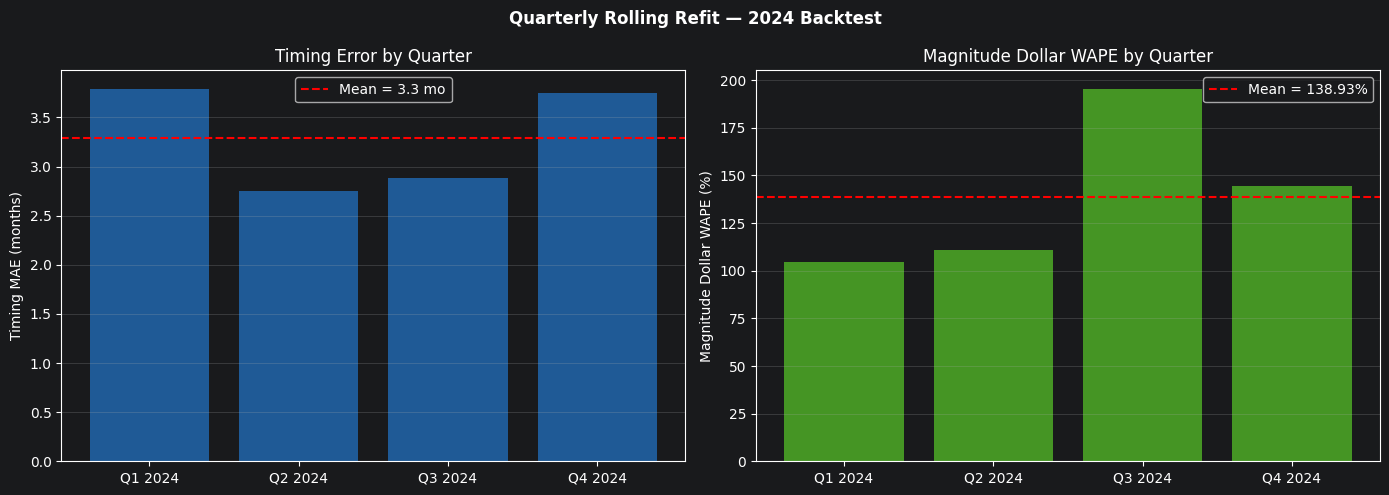

In [11]:
# ── Quarterly Rolling Refit Backtest — 2024 ──
# Q1: train on <2024-01-01  →  evaluate on spells starting Jan–Mar 2024
# Q2: train on <2024-04-01  →  evaluate on spells starting Apr–Jun 2024
# Q3: train on <2024-07-01  →  evaluate on spells starting Jul–Sep 2024
# Q4: train on <2024-10-01  →  evaluate on spells starting Oct–Dec 2024

quarters = [
    ("Q1 2024", pd.Timestamp("2024-01-01"), pd.Timestamp("2024-04-01")),
    ("Q2 2024", pd.Timestamp("2024-04-01"), pd.Timestamp("2024-07-01")),
    ("Q3 2024", pd.Timestamp("2024-07-01"), pd.Timestamp("2024-10-01")),
    ("Q4 2024", pd.Timestamp("2024-10-01"), pd.Timestamp("2025-01-01")),
]

quarterly_results = []
for label, q_start, q_end in quarters:
    print(f"  {label}...", end=" ", flush=True)
    train_sp = surv_df[surv_df["SPELL_START_DATE"] < q_start].copy()
    val_sp   = surv_df[(surv_df["SPELL_START_DATE"] >= q_start) &
                       (surv_df["SPELL_START_DATE"] <  q_end)].copy()
    result = run_window(train_sp, val_sp, label, val_end=q_end)
    if result:
        quarterly_results.append(result)
        print(f"done  C={result['c_index']:.4f}  t_mae={result['timing_mae']}mo  wape={result['mag_dollar_wape']}%")
    else:
        print("skipped (insufficient data)")

q_df = pd.DataFrame(quarterly_results)
print("\n" + "="*90)
print("  QUARTERLY ROLLING BACKTEST — 2024")
print("="*90)
print(q_df[["window","train_spells","val_spells","val_events","c_index",
            "timing_mae","timing_med","timing_w3m","mag_dollar_wape","mag_med_pct_err","mag_w1pct","mag_w2pct"]].to_string(index=False))
print("="*90)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Quarterly Rolling Refit — 2024 Backtest", fontweight="bold")

axes[0].bar(q_df["window"], q_df["timing_mae"], color="#2166AC", alpha=0.85)
axes[0].axhline(q_df["timing_mae"].mean(), color="red", linestyle="--",
                label=f'Mean = {q_df["timing_mae"].mean():.1f} mo')
axes[0].set_ylabel("Timing MAE (months)"); axes[0].set_title("Timing Error by Quarter")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(q_df["window"], q_df["mag_dollar_wape"].astype(float), color="#4DAC26", alpha=0.85)
axes[1].axhline(q_df["mag_dollar_wape"].astype(float).mean(), color="red", linestyle="--",
                label=f'Mean = {q_df["mag_dollar_wape"].astype(float).mean():.2f}%')
axes[1].set_ylabel("Magnitude Dollar WAPE (%)"); axes[1].set_title("Magnitude Dollar WAPE by Quarter")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()


In [ ]:
# ── Semi-Annual Rolling Refit Backtest — 2024 ──
# H1: train on <2024-01-01  →  evaluate on spells starting Jan–Jun 2024
# H2: train on <2024-07-01  →  evaluate on spells starting Jul–Dec 2024

halves = [
    ("H1 2024", pd.Timestamp("2024-01-01"), pd.Timestamp("2024-07-01")),
    ("H2 2024", pd.Timestamp("2024-07-01"), pd.Timestamp("2025-01-01")),
]

semi_results = []
for label, h_start, h_end in halves:
    print(f"  {label}...", end=" ", flush=True)
    train_sp = surv_df[surv_df["SPELL_START_DATE"] < h_start].copy()
    val_sp   = surv_df[(surv_df["SPELL_START_DATE"] >= h_start) &
                       (surv_df["SPELL_START_DATE"] <  h_end)].copy()
    result = run_window(train_sp, val_sp, label, val_end=h_end)
    if result:
        semi_results.append(result)
        print(f"done  C={result['c_index']:.4f}  t_mae={result['timing_mae']}mo  wape={result['mag_dollar_wape']}%")
    else:
        print("skipped")

s_df = pd.DataFrame(semi_results)
print("\n" + "="*90)
print("  SEMI-ANNUAL ROLLING REFIT BACKTEST — 2024")
print("="*90)
print(s_df[["window","train_spells","val_spells","val_events","c_index",
            "timing_mae","timing_med","timing_w3m","mag_dollar_wape","mag_med_pct_err","mag_w1pct","mag_w2pct"]].to_string(index=False))
print("="*90)

# ── Combined comparison plot ──
all_windows = pd.concat([q_df, s_df], ignore_index=True)
colors      = ["#2166AC"]*4 + ["#D6604D"]*2

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Quarterly vs Semi-Annual: All 2024 Windows", fontweight="bold")

axes2[0].bar(all_windows["window"], all_windows["timing_mae"].astype(float), color=colors, alpha=0.85)
axes2[0].set_ylabel("Timing MAE (months)"); axes2[0].set_title("Timing Error by Window")
axes2[0].grid(True, alpha=0.3, axis="y")

axes2[1].bar(all_windows["window"], all_windows["mag_dollar_wape"].astype(float), color=colors, alpha=0.85)
axes2[1].set_ylabel("Magnitude Dollar WAPE (%)"); axes2[1].set_title("Magnitude Dollar WAPE by Window")
axes2[1].grid(True, alpha=0.3, axis="y")

from matplotlib.patches import Patch
axes2[0].legend(handles=[Patch(color="#2166AC", label="Quarterly"),
                          Patch(color="#D6604D", label="Semi-Annual")])
plt.tight_layout(); plt.show()

# ── Final summary comparison ──
print("\n  METHOD COMPARISON SUMMARY")
print(f"  {'Method':<22} {'Avg C-index':>12} {'Avg Timing MAE':>16} {'Avg Mag MAE':>13} {'Timing ≤3mo':>12}")
print(f"  {'-'*22} {'-'*12} {'-'*16} {'-'*13} {'-'*12}")
for lbl, df_ in [("Quarterly refit", q_df), ("Semi-annual refit", s_df)]:
    print(f"  {lbl:<22} {df_['c_index'].mean():>12.4f} "
          f"{df_['timing_mae'].astype(float).mean():>15.1f}mo "
          f"{df_['mag_dollar_wape'].astype(float).mean():>12.2f}% "
          f"{df_['timing_w3m'].astype(float).mean():>11.1f}%")


  H1 2024... done  C=0.7490  t_mae=3.51mo  wape=103.12%
  H2 2024... 

In [ ]:
# ── Predicted Survival Curves for Selected Drugs ──
# Shows predicted P(no increase by month T) for a few representative drugs.

top500 = pd.read_csv("/Users/vishnu.gorur/PycharmProjects/JupyterProject/data/real_data/Top_500_revenueproducts.csv")
top500 = top500[top500["RUN_ID"] == "BT_2024_01"]

# Pick top-10 revenue drugs present in surv_df
top_mtrls = top500.drop_duplicates("MTRL_NUM").sort_values("REVENUE_RANK").head(10)
sample = feat_df[feat_df["COPA_MTRL_NUM"].isin(top_mtrls["MTRL_NUM"].values)]
sample = sample.merge(top_mtrls[["MTRL_NUM","REVENUE_RANK","MATERIAL_NAME"]], 
                      left_on="COPA_MTRL_NUM", right_on="MTRL_NUM", how="left")
# Keep most recent spell per material
sample = sample.sort_values("n_prior_changes", ascending=False).drop_duplicates("COPA_MTRL_NUM")

X_sample = sample[FEATURES].fillna(0).values.astype(float)
surv_fns  = gbts.predict_survival_function(X_sample)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(sample)))

for i, (fn, (_, row)) in enumerate(zip(surv_fns, sample.iterrows())):
    label = f"Rank {int(row['REVENUE_RANK'])}: {row['MATERIAL_NAME'][:25]}"
    ax.step(fn.x, fn(fn.x), where="post", linewidth=1.8, label=label, color=colors[i])

ax.set_xlabel("Months since last price change")
ax.set_ylabel("P(no price increase)")
ax.set_title("GBT Survival — Predicted Time to Next WAC Increase (top-10 revenue drugs)")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7.5, loc="upper right")
plt.tight_layout()
plt.show()

# Print median survival (months to 50% probability of increase)
print(f"\n{'Rank':<6} {'Material':<40} {'Median months to PI':>20}")
print("-"*68)
for fn, (_, row) in zip(surv_fns, sample.iterrows()):
    times = fn.x
    probs = fn(times)
    below = times[probs <= 0.5]
    median = below[0] if len(below) > 0 else ">52"
    print(f"{int(row['REVENUE_RANK']):<6} {row['MATERIAL_NAME']:<40} {str(median):>20}")
